--- Lojistik Regresyon Sınıflandırma Raporu ---
              precision    recall  f1-score   support

         0.0       0.95      0.69      0.80     80054
         1.0       0.25      0.74      0.37     10991

    accuracy                           0.70     91045
   macro avg       0.60      0.72      0.59     91045
weighted avg       0.87      0.70      0.75     91045



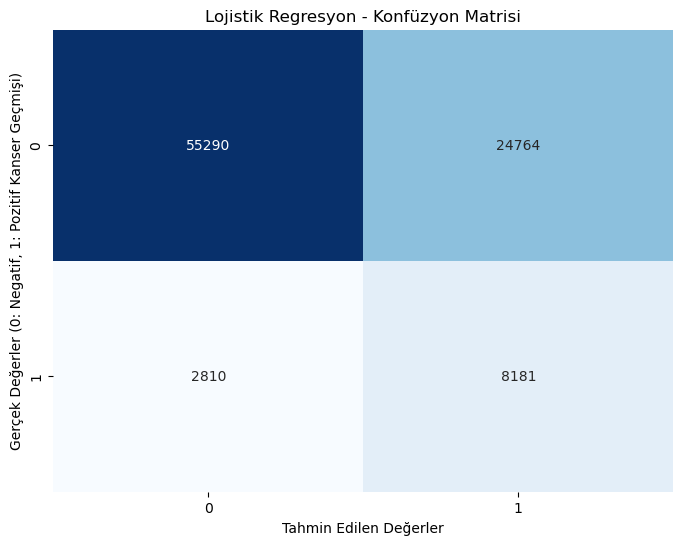

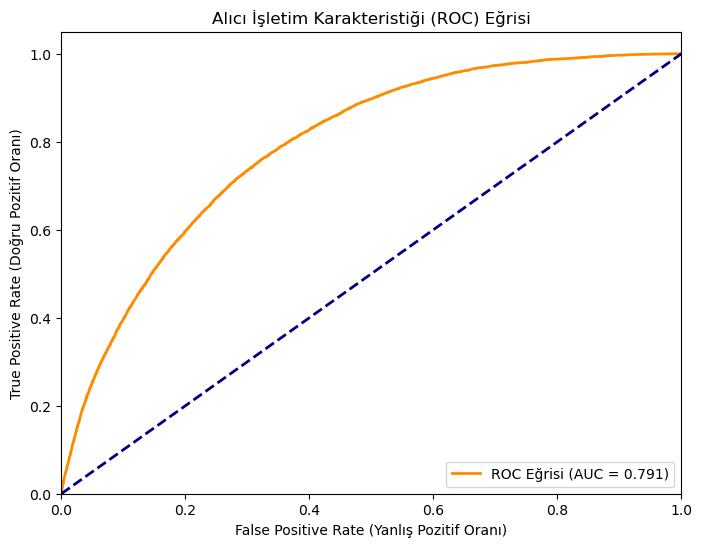

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

y_true_df = pd.read_csv('y_test_hazir.csv')
y_true = y_true_df.iloc[:, 0].values

y_pred = np.load('y_pred_lr.npy')
y_prob = np.load('y_prob_lr.npy')

print("Lojistik Regresyon Sınıflandırma Raporu")
print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Lojistik Regresyon - Konfüzyon Matrisi')
plt.ylabel('Gerçek Değerler (0: Negatif, 1: Pozitif Kanser Geçmişi)')
plt.xlabel('Tahmin Edilen Değerler')
plt.show()

fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Eğrisi (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Yanlış Pozitif Oranı)')
plt.ylabel('True Positive Rate (Doğru Pozitif Oranı)')
plt.title('Alıcı İşletim Karakteristiği (ROC) Eğrisi')
plt.legend(loc="lower right")
plt.show()